In [ ]:
# first cell just imports all the necessary packages, functions, and classes
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))
from analysis_classes import *
from analysis_funcs_and_consts import *
#set font to arial
plt.rcParams['font.family'] = 'Arial'

In [2]:
#auto reload
%load_ext autoreload
%autoreload 2
from analysis_classes import *
from analysis_funcs_and_consts import *

In [29]:
with open('data_analysis/result_dictionaries/FR_mats_with_halves_all_cells.pkl', 'rb') as f:
    FR_mats_with_halves_all_cells = pickle.load(f)
with open('data_analysis/result_dictionaries/is_PC_with_halves_all_cells.pkl', 'rb') as f:
    is_PC_with_halves_all_cells = pickle.load(f)
with open('data_analysis/result_dictionaries/speed_r_vals_with_halves_all_cells.pkl', 'rb') as f:
    speed_r_vals_with_halves_all_cells = pickle.load(f)
with open('data_analysis/result_dictionaries/is_speed_tuned_with_halves_all_cells.pkl', 'rb') as f:
    is_speed_tuned_with_halves_all_cells = pickle.load(f)
with open('data_analysis/result_dictionaries/inst_speed_r_vals_with_halves_all_cells.pkl', 'rb') as f:
    inst_speed_r_vals_with_halves_all_cells = pickle.load(f)
with open('data_analysis/result_dictionaries/is_spatially_modulated_all_cells.pkl', 'rb') as f:
    is_spatially_modulated_all_cells = pickle.load(f)


In [3]:
#just to get a dictionary with all cells
db_Analysis = DB_Analysis()
db_conditions = {(True, STRAIN) :['CKII', 'SST']} # get both CKII and SST cells
cell_objects = db_Analysis.collect_cells(db_conditions, all=False)

# 6a

In [6]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

def plot_single_cell_heatmap(cell,part='first_half',save=False, with_colorbar=False,max_val=None):
    FR_mat = FR_mats_with_halves_all_cells[cell.strain][cell.name][part]
    FR_vec=np.mean(FR_mat,axis=0)
    FR_vec = smooth(FR_vec,3)
    if max_val == None:
        max_val=np.round(np.max(FR_vec),1)
    figsize_mm = (16, 16)
    if with_colorbar:
        # Add extra space for the colorbar, e.g., 5mm
        additional_width_mm = figsize_mm[0] * (0.335) # 20 * 0.15 = 3mm 0.05 is for the colorbar, 0.1 is for the padding
        figsize_mm = (figsize_mm[0] + additional_width_mm, figsize_mm[1])
    figsize_inch = (figsize_mm[0] / 25.4, figsize_mm[1] / 25.4)
    fig, ax = plt.subplots(figsize=figsize_inch)

    img = ax.imshow(FR_mat, aspect='auto', cmap='viridis')
    yticks_labels = [FR_mat.shape[0]]
    plt.yticks([FR_mat.shape[0] - 1], yticks_labels, fontsize=SVG_TICKS)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.set_tick_params(width=0,pad=0)

    ax2 = ax.twinx()
    ax2.plot(FR_vec, color='#e6e6e6', linewidth=1)
    ax2.set_ylim(0, max_val)

    ax2.set_yticks([])
    if cell.name == 'SRK1_X_39_1':
        xticks_labels = [0, 160]
        ax.set_xticks([0, 47], xticks_labels, fontsize=SVG_TICKS)
    else:
        ax.set_xticks([])

    #remove top and right spines
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.yaxis.set_tick_params(width=0,pad=0)
    img.set_clim(0, max_val*2) #used to be 0, max_val*1.5
    # make background transparent
    fig.patch.set_alpha(0)
    if with_colorbar:
        cbar = fig.colorbar(img, ax=ax, orientation='vertical', pad=0.1, aspect=15)#, shrink=0.5)
        cbar.set_ticks([0, max_val*2])
        cbar.set_ticklabels([0, max_val*2])
        cbar.ax.tick_params(labelsize=SVG_TICKS)
        cbar.outline.set_visible(False)
        cbar.ax.yaxis.set_tick_params(width=0,pad=0)
    if save:
        plt.savefig(r"folder_path_here" + f"{cell.name}_{part}_heatmap.svg", format='svg', dpi=300, bbox_inches='tight')

    plt.show()

def plot_cell_pair_heatmap(cell1, cell2, part='first_half', save=False, with_colorbar=False):
    FR_mat1 = FR_mats_with_halves_all_cells[cell1.strain][cell1.name][part]
    FR_mat2 = FR_mats_with_halves_all_cells[cell2.strain][cell2.name][part]
    FR_vec1 = np.mean(FR_mat1, axis=0)
    FR_vec2 = np.mean(FR_mat2, axis=0)
    FR_vec1 = smooth(FR_vec1, 3)
    FR_vec2 = smooth(FR_vec2, 3)
    max_val = np.round(np.max([FR_vec1, FR_vec2]), 1)
    for cell in [cell1, cell2]:
        if cell==cell1:   
            plot_single_cell_heatmap(cell, part=part, save=save, with_colorbar=False, max_val=max_val)
        else:
            plot_single_cell_heatmap(cell, part=part, save=save, with_colorbar=with_colorbar, max_val=max_val)

def plot_single_cell_heatmap_for_PDF(cell, ax, part='first_half', max_val=None):
    FR_mat = FR_mats_with_halves_all_cells[cell.strain][cell.name][part]
    FR_vec = smooth(np.mean(FR_mat, axis=0), 3)
    if max_val is None:
        max_val = np.round(np.max(FR_vec), 1)

    # Plot heatmap
    img = ax.imshow(FR_mat, aspect='auto', cmap='viridis')
    img.set_clim(0, max_val * 2)  # Consistent with your other code

    # Y ticks: show just lap count or minimal
    ax.set_yticks([FR_mat.shape[0] - 1])
    ax.set_yticklabels([FR_mat.shape[0]], fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.set_tick_params(width=0, pad=0)

    # No x ticks (except for special case)
    if cell.name == 'SRK1_X_39_1':
        ax.set_xticks([0, 47])
        ax.set_xticklabels([0, 160], fontsize=SVG_TICKS)
    else:
        ax.set_xticks([])

    # Overlay trace
    ax2 = ax.twinx()
    ax2.plot(FR_vec, color='#e6e6e6', linewidth=1)
    ax2.set_ylim(0, max_val)
    ax2.set_yticks([])
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.yaxis.set_tick_params(width=0, pad=0)

    # Transparent background
    ax.figure.patch.set_alpha(0)



### Single cell examples, correlated

COP7_R1_4_2 - COP7_R1_16_2


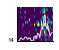

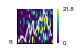

RCK10_X_7_3 - RCK10_X_18_3


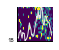

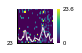

SRK1_R1_32_3 - SRK1_R1_46_a_3


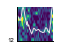

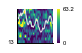

In [7]:
cells_lst=[]
example_cells = ["COP7_R1_4_2", "COP7_R1_16_2","RCK10_X_7_3","RCK10_X_18_3","SRK1_R1_32_3","SRK1_R1_46_a_3"] #"CRK8_X_4_6","CRK8_X_21_6"
for cell in cell_objects:
    if cell.name in example_cells:
        cells_lst.append(cell)

sorted_pairs = sorted(zip(cells_lst[::2], cells_lst[1::2]), key=lambda x: x[0].intseq)
#sort each pair by the intseq
sorted_pairs = [(cell1, cell2) if cell1.intseq < cell2.intseq else (cell2, cell1) for cell1, cell2 in sorted_pairs]
#print the names of the cells in the pairs
for cell1, cell2 in sorted_pairs:
    print(f"{cell1.name} - {cell2.name}")
    plot_cell_pair_heatmap(cell1, cell2, part='first_half', save=False, with_colorbar=True)

### Single cell examples, uncorrelated

COP7_R1_23_5 - COP7_R1_35_5


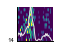

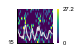

SRK1_X_32_1 - SRK1_X_45_1


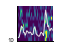

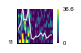

In [8]:
cell_lst_uncorrelated = []
example_cells_uncorrelated = ["COP7_R1_23_5", "COP7_R1_35_5","SRK1_X_32_1","SRK1_X_45_1"]
for cell in cell_objects:
    if cell.name in example_cells_uncorrelated:
        cell_lst_uncorrelated.append(cell)

sorted_pairs_uncor = sorted(zip(cell_lst_uncorrelated[::2], cell_lst_uncorrelated[1::2]), key=lambda x: x[0].intseq)
#sort each pair by the intseq
sorted_pairs_uncor = [(cell1, cell2) if cell1.intseq < cell2.intseq else (cell2, cell1) for cell1, cell2 in sorted_pairs_uncor]
#print the names of the cells in the pairs
for cell1, cell2 in sorted_pairs_uncor:
    print(f"{cell1.name} - {cell2.name}")
    plot_cell_pair_heatmap(cell1, cell2, part='first_half', save=True, with_colorbar=True)


# 6b

In [5]:
def find_all_sessions_of_cell(cell_identity):
    # Find all sessions of the cell with the given identity
    sessions = []
    for cell in cell_objects:
        if cell.identity == cell_identity:
            sessions.append(cell)
    return sessions

def find_all_sessions_of_cell_no_remapping(cell_identity):
    # Find all sessions of the cell with the given identity
    sessions = []
    for cell in cell_objects:
        if cell.identity == cell_identity and cell.remapping == False:
            sessions.append(cell)
    return sessions

def sort_sessions_by_intseq(cell_sessions):
    # Sort the sessions by intseq
    session_intseq = [x.intseq for x in cell_sessions]
    sorted_sessions = [x for _, x in sorted(zip(session_intseq, cell_sessions), key=lambda pair: pair[0])]
    return sorted_sessions

def get_session_pairs_by_time_interval(sorted_sessions, time_interval=[12,16]):
    if len(sorted_sessions) < 2:
        # print("Not enough sessions to compare.")
        return {}
    dates = [session.metadata[EXPERIMENT_DATE] for session in sorted_sessions]
    # Convert dates to datetime objects
    dates = [datetime.strptime(date, '%Y-%m-%d') for date in dates]
    # Get sessions that are within the specified tinterval of days
    relevant_pairs = {}
    count=1
    # print(f"ID - {sorted_sessions[0].identity}")
    for i in range(len(dates)-1):
        days_diff = (dates[i+1] - dates[i]).days
        # print(f"Days difference between {dates[i].strftime('%Y-%m-%d')} and {dates[i+1].strftime('%Y-%m-%d')}: {days_diff} days")
        if (days_diff >= time_interval[0]) and (days_diff <= time_interval[1]):
            relevant_pairs[f'pair_{count}'] = [sorted_sessions[i], sorted_sessions[i+1]]
            count+=1
    return relevant_pairs

def get_session_pairs_by_time_interval_first_one_is_reg(sorted_sessions, time_interval=[12,16]):
    if len(sorted_sessions) < 2:
        # print("Not enough sessions to compare.")
        return {}
    dates = [session.metadata[EXPERIMENT_DATE] for session in sorted_sessions]
    # Convert dates to datetime objects
    dates = [datetime.strptime(date, '%Y-%m-%d') for date in dates]
    # Get sessions that are within the specified tinterval of days
    relevant_pairs = {}
    count=1
    # print(f"ID - {sorted_sessions[0].identity}")
    for i in range(len(dates)-1):
        days_diff = (dates[i+1] - dates[i]).days
        # print(f"Days difference between {dates[i].strftime('%Y-%m-%d')} and {dates[i+1].strftime('%Y-%m-%d')}: {days_diff} days")
        if (days_diff >= time_interval[0]) and (days_diff <= time_interval[1]):
            # Check if the first session is a regular session (not remapped)
            if sorted_sessions[i].remapping == False:
                relevant_pairs[f'pair_{count}'] = [sorted_sessions[i], sorted_sessions[i+1]]
                count+=1
    return relevant_pairs

def get_session_pairs_by_time_interval_first_one_is_reg_second_remap(sorted_sessions, time_interval=[12,16]):
    if len(sorted_sessions) < 2:
        # print("Not enough sessions to compare.")
        return {}
    dates = [session.metadata[EXPERIMENT_DATE] for session in sorted_sessions]
    # Convert dates to datetime objects
    dates = [datetime.strptime(date, '%Y-%m-%d') for date in dates]
    # Get sessions that are within the specified tinterval of days
    relevant_pairs = {}
    count=1
    # print(f"ID - {sorted_sessions[0].identity}")
    for i in range(len(dates)-1):
        days_diff = (dates[i+1] - dates[i]).days
        # print(f"Days difference between {dates[i].strftime('%Y-%m-%d')} and {dates[i+1].strftime('%Y-%m-%d')}: {days_diff} days")
        if (days_diff >= time_interval[0]) and (days_diff <= time_interval[1]):
            # Check if the first session is a regular session (not remapped)
            if sorted_sessions[i].remapping == False and sorted_sessions[i+1].remapping == True:
                relevant_pairs[f'pair_{count}'] = [sorted_sessions[i], sorted_sessions[i+1]]
                count+=1
    return relevant_pairs

def get_session_pair_with_max_laps(
    cell_id,
    time_interval=[12, 16],
    include_remap=False, #must include remapping for the other two flags to make sense
    require_first_regular=True,
    require_first_regular_second_remap=False
):
    """
    Selects the session pair for a given cell that has the highest total number of laps,
    among those whose session dates fall within the specified time interval.

    Parameters:
        cell_id (str): Identifier of the cell.
        time_interval (list of int): [min_days, max_days] between the two sessions.
        include_remap (bool): If True, include remapping sessions; otherwise exclude them.
        require_first_regular (bool): If True, require the first session to be regular.
        require_second_remap (bool): If True, require the second session to be a remap.
                                     Ignored if `require_first_regular` is True.

    Returns:
        list: A session pair [session1, session2] with the most combined laps,
              or an empty dict if no valid pair is found.
    """
    # Get sessions for the cell
    if include_remap:
        sessions = find_all_sessions_of_cell(cell_id)
    else:
        sessions = find_all_sessions_of_cell_no_remapping(cell_id)

    sorted_sessions = sort_sessions_by_intseq(sessions)

    # Select session pairs based on input flags
    if require_first_regular:
        relevant_pairs = get_session_pairs_by_time_interval_first_one_is_reg(
            sorted_sessions, time_interval
        )
    elif require_first_regular_second_remap:
        relevant_pairs = get_session_pairs_by_time_interval_first_one_is_reg_second_remap(
            sorted_sessions, time_interval
        )
    else:
        relevant_pairs = get_session_pairs_by_time_interval(
            sorted_sessions, time_interval
        )

    if not relevant_pairs:
        return {}

    # Find the pair with the maximum total number of laps
    max_pair = max(
        relevant_pairs.values(),
        key=lambda pair: (
            FR_mats_with_halves_all_cells[pair[0].strain][pair[0].name]['full'].shape[0] +
            FR_mats_with_halves_all_cells[pair[1].strain][pair[1].name]['full'].shape[0]
        )
    )

    return max_pair

def get_session_pair_by_PC(
    cell_id,
    time_interval=[12, 16],
    include_remap=False,
    require_first_regular=True,
    require_first_regular_second_remap=False
):
    """
    Selects the session pair for a given cell with the following priority:
        1. Both sessions have at least 10 laps
        2. First session is a full place cell
        3. Second session is a first-half place cell
        4. Highest total number of laps
    """

    if include_remap:
        sessions = find_all_sessions_of_cell(cell_id)
    else:
        sessions = find_all_sessions_of_cell_no_remapping(cell_id)

    sorted_sessions = sort_sessions_by_intseq(sessions)

    if require_first_regular:
        relevant_pairs = get_session_pairs_by_time_interval_first_one_is_reg(
            sorted_sessions, time_interval
        )
    elif require_first_regular_second_remap:
        relevant_pairs = get_session_pairs_by_time_interval_first_one_is_reg_second_remap(
            sorted_sessions, time_interval
        )
    else:
        relevant_pairs = get_session_pairs_by_time_interval(
            sorted_sessions, time_interval
        )

    if not relevant_pairs:
        return {}

    def pair_priority(pair):
        s1, s2 = pair
        mat1 = FR_mats_with_halves_all_cells[s1.strain][s1.name]['full']
        mat2 = FR_mats_with_halves_all_cells[s2.strain][s2.name]['full']
        laps1 = mat1.shape[0]
        laps2 = mat2.shape[0]

        both_min_10 = (laps1 >= 10 and laps2 >= 10)
        s1_is_pc = is_PC_with_halves_all_cells[s1.strain][s1.name].get('full', False)
        s2_is_pc = is_PC_with_halves_all_cells[s2.strain][s2.name].get('first_half', False)
        total_laps = laps1 + laps2

        # Return a tuple for max() to sort by
        return (both_min_10, s1_is_pc, s2_is_pc, total_laps)

    best_pair = max(relevant_pairs.values(), key=pair_priority)

    return best_pair


    
    

    


    


In [7]:
all_heatmaps = []
time_interval = [11,15] # sessions are 11 to 15 days apart
bins_num = 48
smooth_fac=3

CKII_count = 0 ; CKII_count_PC = {'W0':0, 'W2':0}
SST_count = 0 ; SST_count_PC = {'W0':0, 'W2':0}
CKII_mat_1 = np.zeros(bins_num); CKII_mat_2 = np.zeros(bins_num) ; CKII_mat_3 = np.zeros(bins_num)
SST_mat_1 = np.zeros(bins_num); SST_mat_2 = np.zeros(bins_num) ; SST_mat_3 = np.zeros(bins_num)
results_dict_to_export = {}
for strain in ["CKII", "SST"]:
    all_strain_IDs = list(set(cell.identity for cell in cell_objects if cell.strain == strain))
    for id in all_strain_IDs:
        max_pair = get_session_pair_by_PC(
            id,
            time_interval=time_interval,
            include_remap=True,
            require_first_regular=True,
            require_first_regular_second_remap=False
        )
        if len(max_pair) == 0:
            continue
        if (
            (is_PC_with_halves_all_cells[max_pair[0].strain][max_pair[0].name]['full'] == True) or
            (max_pair[1].remapping == True and is_PC_with_halves_all_cells[max_pair[1].strain][max_pair[1].name]['first_half'] == True) or
            (max_pair[1].remapping == False and is_PC_with_halves_all_cells[max_pair[1].strain][max_pair[1].name]['full'] == True)
        ):
            mat1 = FR_mats_with_halves_all_cells[max_pair[0].strain][max_pair[0].name]['first_half'] 
            mat2 = FR_mats_with_halves_all_cells[max_pair[0].strain][max_pair[0].name]['second_half']
            mat3 = FR_mats_with_halves_all_cells[max_pair[1].strain][max_pair[1].name]['first_half']
            # if mat2.shape[0] < 8 or mat1.shape[0] < 8 or mat3.shape[0] < 8:
            if mat2.shape[0] < 1 or mat1.shape[0] < 1 or mat3.shape[0] < 1:
                continue
            vec1 = normalize(smooth(np.mean(mat1, axis=0), smooth_fac))
            vec2 = normalize(smooth(np.mean(mat2, axis=0), smooth_fac))
            vec3 = normalize(smooth(np.mean(mat3, axis=0), smooth_fac))
            if strain == 'CKII':
                CKII_count += 1
                CKII_mat_1 = np.vstack((CKII_mat_1, vec1))
                CKII_mat_2 = np.vstack((CKII_mat_2, vec2))
                CKII_mat_3 = np.vstack((CKII_mat_3, vec3))
            else:
                SST_count += 1
                SST_mat_1 = np.vstack((SST_mat_1, vec1))
                SST_mat_2 = np.vstack((SST_mat_2, vec2))
                SST_mat_3 = np.vstack((SST_mat_3, vec3))

            results_dict_to_export[max_pair[0].identity] = {
                'Strain': max_pair[0].strain,
                'FR_vec_W0_first_half': vec1,
                'FR_vec_W0_second_half': vec2,
                'FR_vec_W2_first_half': vec3
            }


if CKII_mat_1.ndim > 1:
    CKII_mat_1 = CKII_mat_1[1:]
    CKII_mat_2 = CKII_mat_2[1:]
    CKII_mat_3 = CKII_mat_3[1:]
    sorted_CKII_mat_1, sorted_indices_CKII = sort_rows_by_max_index(CKII_mat_1)
    sorted_CKII_mat_2 = CKII_mat_2[sorted_indices_CKII]
    sorted_CKII_mat_3 = CKII_mat_3[sorted_indices_CKII]
else:
    sorted_CKII_mat_1 = CKII_mat_1
    sorted_CKII_mat_2 = CKII_mat_2
    sorted_CKII_mat_3 = CKII_mat_3

if SST_mat_1.ndim > 1:
    SST_mat_1 = SST_mat_1[1:]
    SST_mat_2 = SST_mat_2[1:]
    SST_mat_3 = SST_mat_3[1:]
    sorted_SST_mat_1, sorted_indices_SST = sort_rows_by_max_index(SST_mat_1)
    sorted_SST_mat_2 = SST_mat_2[sorted_indices_SST]
    sorted_SST_mat_3 = SST_mat_3[sorted_indices_SST]
else:
    sorted_SST_mat_1 = np.vstack((SST_mat_1, SST_mat_1))
    sorted_SST_mat_2 = np.vstack((SST_mat_2, SST_mat_2))
    sorted_SST_mat_3 = np.vstack((SST_mat_3, SST_mat_3))




if CKII_count > 0 or SST_count > 0:
    all_heatmaps.append({
        'interval': time_interval,
        'CKII1': sorted_CKII_mat_1,
        'CKII2': sorted_CKII_mat_2,
        'CKII3': sorted_CKII_mat_3,
        'SST1': sorted_SST_mat_1,
        'SST2': sorted_SST_mat_2,
        'SST3': sorted_SST_mat_3
    })





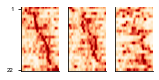

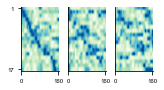

In [8]:
def plot_heatmaps(mat1, mat2, mat3, cmap, bins_num, SVG_TICKS, figsize_mm=(80, 40),save_flag=False,strain='CKII'):
    figsize_inch = (figsize_mm[0]/25.4, figsize_mm[1]/25.4)
    fig, ax = plt.subplots(1, 3, figsize=figsize_inch)
    
    for i, mat in enumerate([mat1, mat2, mat3]):
        #normalize each row between 0 and 1
        mat = (mat - np.min(mat, axis=1, keepdims=True)) / (np.max(mat, axis=1, keepdims=True) - np.min(mat, axis=1, keepdims=True) + 1e-10)
        ax[i].imshow(mat, aspect='auto', cmap=cmap)
        ax[i].set_yticks([0, len(mat)-1], [1, len(mat)], fontsize=SVG_TICKS)
        ax[i].tick_params(axis='y', labelsize=SVG_TICKS)  # Set the fontsize for y-ticks
        ax[i].set_xticks([0, bins_num-1])
        if strain == 'SST':
            ax[i].set_xticklabels([0, 160], fontsize=SVG_TICKS)
        else:
            ax[i].set_xticks([])
        ax[i].spines['top'].set_visible(False)
        ax[i].spines['right'].set_visible(False)
        if i > 0:  # Only remove y-ticks for the second and third plots
            ax[i].set_yticks([])

    # Add spacing between the subplots
    plt.subplots_adjust(wspace=0.25)
    if save_flag:
        plt.savefig(r"your_save_path_here" + f"{strain}_heatmaps.svg", format='svg', dpi=300, bbox_inches='tight')
    plt.show()

# For CKII heatmaps
plot_heatmaps(sorted_CKII_mat_1, sorted_CKII_mat_2, sorted_CKII_mat_3, cmap='OrRd', bins_num=bins_num, SVG_TICKS=SVG_TICKS,save_flag=True,strain='CKII',figsize_mm=(60, 30)) #smaller size was (55, 25)

# For SST heatmaps
plot_heatmaps(sorted_SST_mat_1, sorted_SST_mat_2, sorted_SST_mat_3, cmap='GnBu', bins_num=bins_num, SVG_TICKS=SVG_TICKS,save_flag=True,strain='SST',figsize_mm=(60, 30)) #prev size was (60, 35)


# 6c+6d

In [10]:
def rowise_metric_means(mat1, mat2, metric_type='COM_dist'):
    dists_or_corrs = []
    
    for i in np.arange(mat1.shape[0]):  # matrices should be of the same size
        FR_vec1 = mat1[i,:]
        FR_vec2 = mat2[i,:]
        cm_per_bin = 160 / len(FR_vec1)  
        if metric_type == 'COM_dist':
            COM1 = np.sum([i * FR_vec1[i] for i in np.arange(len(FR_vec1))]) / np.sum(FR_vec1)
            COM2 = np.sum([i * FR_vec2[i] for i in np.arange(len(FR_vec2))]) / np.sum(FR_vec2)
            dist = abs(COM1 - COM2)
            dist_cm = dist * cm_per_bin  # convert to cm
            dists_or_corrs.append(dist_cm)
        
        elif metric_type == 'EUC_dist':
            dist = np.linalg.norm(FR_vec1 - FR_vec2)
            dists_or_corrs.append(dist)
        
        elif metric_type == 'corr':
            corr = np.corrcoef(FR_vec1, FR_vec2)[0, 1]
            dists_or_corrs.append(corr)

        elif metric_type == 'mean_FR_diff':
            mean_FR1 = np.mean(FR_vec1)
            mean_FR2 = np.mean(FR_vec2)
            dist = abs(mean_FR1 - mean_FR2)
            dists_or_corrs.append(dist)   

        elif metric_type == 'mean_FR_diff_normed':
            mean_FR1 = np.mean(FR_vec1)
            mean_FR2 = np.mean(FR_vec2)
            dist = abs(mean_FR1 - mean_FR2) / np.mean(mean_FR1)
            dists_or_corrs.append(dist)
    return np.mean(dists_or_corrs)


def generate_n_shuffled_means(mat1,mat2,metric_type='COM_dist',n_shuffles=1000):
    observed_mean = rowise_metric_means(mat1, mat2, metric_type)
    shuffled_means = []
    for i in np.arange(n_shuffles):
        shuffled_mat1 = np.random.permutation(mat1)
        shuffled_mat2 = np.random.permutation(mat2)
        shuffled_means.append(rowise_metric_means(shuffled_mat1, shuffled_mat2, metric_type))
    return observed_mean,shuffled_means

In [11]:
#calculate observed means and shuffled means for all metrics and both strains
observed_mean_CKII_corr_w0, shuffled_means_CKII_corr_w0 = generate_n_shuffled_means(sorted_CKII_mat_1, sorted_CKII_mat_2, metric_type='corr', n_shuffles=1000)
observed_mean_CKII_corr_w2, shuffled_means_CKII_corr_w2 = generate_n_shuffled_means(sorted_CKII_mat_1, sorted_CKII_mat_3, metric_type='corr', n_shuffles=1000)
observed_mean_SST_corr_w0, shuffled_means_SST_corr_w0 = generate_n_shuffled_means(sorted_SST_mat_1, sorted_SST_mat_2, metric_type='corr', n_shuffles=1000)
observed_mean_SST_corr_w2, shuffled_means_SST_corr_w2 = generate_n_shuffled_means(sorted_SST_mat_1, sorted_SST_mat_3, metric_type='corr', n_shuffles=1000)
observed_mean_CKII_COM_w0, shuffled_means_CKII_COM_w0 = generate_n_shuffled_means(sorted_CKII_mat_1, sorted_CKII_mat_2, metric_type='COM_dist', n_shuffles=1000)
observed_mean_CKII_COM_w2, shuffled_means_CKII_COM_w2 = generate_n_shuffled_means(sorted_CKII_mat_1, sorted_CKII_mat_3, metric_type='COM_dist', n_shuffles=1000)
observed_mean_SST_COM_w0, shuffled_means_SST_COM_w0 = generate_n_shuffled_means(sorted_SST_mat_1, sorted_SST_mat_2, metric_type='COM_dist', n_shuffles=1000)
observed_mean_SST_COM_w2, shuffled_means_SST_COM_w2 = generate_n_shuffled_means(sorted_SST_mat_1, sorted_SST_mat_3, metric_type='COM_dist', n_shuffles=1000)
observed_mean_CKII_EUC_w0, shuffled_means_CKII_EUC_w0 = generate_n_shuffled_means(sorted_CKII_mat_1, sorted_CKII_mat_2, metric_type='EUC_dist', n_shuffles=1000)
observed_mean_CKII_EUC_w2, shuffled_means_CKII_EUC_w2 = generate_n_shuffled_means(sorted_CKII_mat_1, sorted_CKII_mat_3, metric_type='EUC_dist', n_shuffles=1000)
observed_mean_SST_EUC_w0, shuffled_means_SST_EUC_w0 = generate_n_shuffled_means(sorted_SST_mat_1, sorted_SST_mat_2, metric_type='EUC_dist', n_shuffles=1000)
observed_mean_SST_EUC_w2, shuffled_means_SST_EUC_w2 = generate_n_shuffled_means(sorted_SST_mat_1, sorted_SST_mat_3, metric_type='EUC_dist', n_shuffles=1000)
shuffeled_means_corr_CKII = [np.mean(shuffled_means_CKII_corr_w0),np.mean(shuffled_means_CKII_corr_w2)]
shuffeled_means_corr_SST = [np.mean(shuffled_means_SST_corr_w0),np.mean(shuffled_means_SST_corr_w2)]
shuffeled_means_COM_CKII = [np.mean(shuffled_means_CKII_COM_w0),np.mean(shuffled_means_CKII_COM_w2)]
shuffeled_means_COM_SST = [np.mean(shuffled_means_SST_COM_w0),np.mean(shuffled_means_SST_COM_w2)]
shuffeled_means_EUC_CKII = [np.mean(shuffled_means_CKII_EUC_w0),np.mean(shuffled_means_CKII_EUC_w2)]
shuffeled_means_EUC_SST = [np.mean(shuffled_means_SST_EUC_w0),np.mean(shuffled_means_SST_EUC_w2)]

observed_mean_CKII_mean_FR_w0, shuffled_means_CKII_mean_FR_w0 = generate_n_shuffled_means(sorted_CKII_mat_1, sorted_CKII_mat_2, metric_type='mean_FR_diff', n_shuffles=1000)
observed_mean_CKII_mean_FR_w2, shuffled_means_CKII_mean_FR_w2 = generate_n_shuffled_means(sorted_CKII_mat_1, sorted_CKII_mat_3, metric_type='mean_FR_diff', n_shuffles=1000)
observed_mean_SST_mean_FR_w0, shuffled_means_SST_mean_FR_w0 = generate_n_shuffled_means(sorted_SST_mat_1, sorted_SST_mat_2, metric_type='mean_FR_diff', n_shuffles=1000)
observed_mean_SST_mean_FR_w2, shuffled_means_SST_mean_FR_w2 = generate_n_shuffled_means(sorted_SST_mat_1, sorted_SST_mat_3, metric_type='mean_FR_diff', n_shuffles=1000)

shuffeld_mean_mean_FR_CKII = [np.mean(shuffled_means_CKII_mean_FR_w0),np.mean(shuffled_means_CKII_mean_FR_w2)]
shuffeld_mean_mean_FR_SST = [np.mean(shuffled_means_SST_mean_FR_w0),np.mean(shuffled_means_SST_mean_FR_w2)]

observed_mean_CKII_mean_FR_w0_normed, shuffled_means_CKII_mean_FR_w0_normed = generate_n_shuffled_means(sorted_CKII_mat_1, sorted_CKII_mat_2, metric_type='mean_FR_diff_normed', n_shuffles=1000)
observed_mean_CKII_mean_FR_w2_normed, shuffled_means_CKII_mean_FR_w2_normed = generate_n_shuffled_means(sorted_CKII_mat_1, sorted_CKII_mat_3, metric_type='mean_FR_diff_normed', n_shuffles=1000)
observed_mean_SST_mean_FR_w0_normed, shuffled_means_SST_mean_FR_w0_normed = generate_n_shuffled_means(sorted_SST_mat_1, sorted_SST_mat_2, metric_type='mean_FR_diff_normed', n_shuffles=1000)
observed_mean_SST_mean_FR_w2_normed, shuffled_means_SST_mean_FR_w2_normed = generate_n_shuffled_means(sorted_SST_mat_1, sorted_SST_mat_3, metric_type='mean_FR_diff_normed', n_shuffles=1000)

shuffeld_mean_mean_FR_CKII_normed = [np.mean(shuffled_means_CKII_mean_FR_w0_normed),np.mean(shuffled_means_CKII_mean_FR_w2_normed)]
shuffeld_mean_mean_FR_SST_normed = [np.mean(shuffled_means_SST_mean_FR_w0_normed),np.mean(shuffled_means_SST_mean_FR_w2_normed)]




In [12]:
def shapiro_test(result_dict):
    # Perform the Shapiro-Wilk test for normality
    W0_W0_values = [res['W0_W0'] for res in result_dict.values()]
    W0_W2_values = [res['W0_W2'] for res in result_dict.values()]
    W0_W0_stat, W0_W0_p = stats.shapiro(W0_W0_values)
    W0_W2_stat, W0_W2_p = stats.shapiro(W0_W2_values)
    print(f"W0-W0: W-stat = {W0_W0_stat}, p-value = {W0_W0_p}")
    print(f"W0-W2: W-stat = {W0_W2_stat}, p-value = {W0_W2_p}")
    return W0_W0_p, W0_W2_p

def paired_ttest(result_dict):
    # Perform the paired t-test
    W0_W0_values = [res['W0_W0'] for res in result_dict.values()]
    W0_W2_values = [res['W0_W2'] for res in result_dict.values()]
    t_stat, p_value = stats.ttest_rel(W0_W0_values, W0_W2_values)
    print(f"t-statistic: {t_stat}, p-value: {p_value}")
    return t_stat, p_value

def wilcoxon_test(result_dict):
    # Perform the Wilcoxon signed-rank test
    W0_W0_values = [res['W0_W0'] for res in result_dict.values()]
    W0_W2_values = [res['W0_W2'] for res in result_dict.values()]
    stat, p_value = stats.wilcoxon(W0_W0_values, W0_W2_values)
    print(f"Wilcoxon statistic: {stat}, p-value: {p_value}")
    return stat, p_value

def get_mean_SEM(result_dict):
    # Calculate mean and SEM
    W0_W0_values = [res['W0_W0'] for res in result_dict.values()]
    W0_W2_values = [res['W0_W2'] for res in result_dict.values()]
    mean_W0_W0 = np.mean(W0_W0_values)
    mean_W0_W2 = np.mean(W0_W2_values)
    sem_W0_W0 = stats.sem(W0_W0_values)
    sem_W0_W2 = stats.sem(W0_W2_values)
    return mean_W0_W0, sem_W0_W0, mean_W0_W2, sem_W0_W2

def calc_p_val_compared_to_shuffled(result_dict,shuffled_means_W0,shuffled_means_W2):
    # Calculate p-value compared to shuffled means
    W0_W0_values = [res['W0_W0'] for res in result_dict.values()]
    W0_W2_values = [res['W0_W2'] for res in result_dict.values()]
    mean_W0_W0 = np.mean(W0_W0_values)
    mean_W0_W2 = np.mean(W0_W2_values)
    p_val_W0 = np.sum(np.array(shuffled_means_W0) >= mean_W0_W0) / len(shuffled_means_W0)
    p_val_W2 = np.sum(np.array(shuffled_means_W2) >= mean_W0_W2) / len(shuffled_means_W2)
    Z_score_W0 = (np.mean(W0_W0_values) - np.mean(shuffled_means_W0)) / np.std(shuffled_means_W0)
    Z_score_W2 = (np.mean(W0_W2_values) - np.mean(shuffled_means_W2)) / np.std(shuffled_means_W2)
    print(f"p-value W0: {p_val_W0}, p-value W2: {p_val_W2}")
    print(f"Z-score W0: {Z_score_W0}, Z-score W2: {Z_score_W2}")
    return p_val_W0, p_val_W2, Z_score_W0, Z_score_W2


In [13]:
def calculate_rowwise_corr_3_hetamaps(mat1, mat2, mat3):
    """
    Calculate the correlation between the same rows of the three matrices
    Store the correlation values in a dictionary with first key - W0_W0 (two halves, mat1-mat2) and second key - W0_W2 (first halves, mat1-mat3)
    """
    corr_dict = {}
    if mat1.shape[0] != mat2.shape[0] or mat1.shape[0] != mat3.shape[0]:
        print("Matrices have different number of rows, cannot calculate correlation.")
        return corr_dict

    for i in range(mat1.shape[0]):
        row1 = mat1[i, :]
        row2 = mat2[i, :]
        row3 = mat3[i, :]

        # Calculate correlation between the two halves (W0_W0)
        corr_W0_W0 = np.corrcoef(row1, row2)[0, 1]

        # Calculate correlation between the first half and the remapping session (W0_W2)
        corr_W0_W2 = np.corrcoef(row1, row3)[0, 1]

        corr_dict[i] = {'W0_W0': corr_W0_W0, 'W0_W2': corr_W0_W2}

    return corr_dict


def calculate_rowwise_COM_distance_3_hetamaps(mat1, mat2, mat3):
    """
    Compute COM distances between rows (spatial activity vectors) in three matrices:
    - mat1: first half of session W0
    - mat2: second half of session W0
    - mat3: first half of session W2

    For each row (cell), compute COM in each matrix and return absolute differences:
    - W0_W0: COM(mat1) vs COM(mat2)
    - W0_W2: COM(mat1) vs COM(mat3)
    """
    dist_dict = {}

    if mat1.shape != mat2.shape or mat1.shape != mat3.shape:
        print("Matrices must have same shape.")
        return dist_dict

    positions = np.arange(mat1.shape[1])  # Assume linear space bins
    cm_per_bin = 160 / mat1.shape[1]  # Convert bins to cm
    positions = np.array(positions, dtype=float)  # Ensure positions are float for calculations
    for i in range(mat1.shape[0]):
        row1 = mat1[i, :]
        row2 = mat2[i, :]
        row3 = mat3[i, :]

        def compute_COM(row):
            total = np.sum(row)
            if total == 0:
                return np.nan  # or use 0 if preferred
            COM = np.sum(row * positions) / total
            COM_cm = COM * cm_per_bin  # Convert to cm
            return COM_cm

        com1 = compute_COM(row1)
        com2 = compute_COM(row2)
        com3 = compute_COM(row3)

        dist_dict[i] = {
            'W0_W0': np.abs(com1 - com2),
            'W0_W2': np.abs(com1 - com3)
        }

    return dist_dict

corrs_CKII = calculate_rowwise_corr_3_hetamaps(sorted_CKII_mat_1, sorted_CKII_mat_2, sorted_CKII_mat_3)
corrs_SST = calculate_rowwise_corr_3_hetamaps(sorted_SST_mat_1, sorted_SST_mat_2, sorted_SST_mat_3)
COM_CKII = calculate_rowwise_COM_distance_3_hetamaps(sorted_CKII_mat_1, sorted_CKII_mat_2, sorted_CKII_mat_3)
COM_SST = calculate_rowwise_COM_distance_3_hetamaps(sorted_SST_mat_1, sorted_SST_mat_2, sorted_SST_mat_3)

Shapiro-Wilk test for CKII W0_W0: ShapiroResult(statistic=0.9487800636167013, pvalue=0.29867158911989766)
Shapiro-Wilk test for CKII W0_W2: ShapiroResult(statistic=0.9375216665189232, pvalue=0.1758980712601237)
data is normally distributed, using paired t-test
Paired t-test for CKII W0_W0 vs W0_W2: TtestResult(statistic=1.556091838072665, pvalue=0.1346291926271882, df=21)

CKII W0_W0 mean: 0.434, SEM: 0.071
CKII W0_W2 mean: 0.294, SEM: 0.066
P-value for CKII W0_W0 vs shuffled: 0.000
P-value for CKII W0_W2 vs shuffled: 0.010
Shapiro-Wilk test for SST W0_W0: ShapiroResult(statistic=0.9340131296367779, pvalue=0.2538431182250609)
Shapiro-Wilk test for SST W0_W2: ShapiroResult(statistic=0.9408059789392278, pvalue=0.32786710977592604)
data is normally distributed, using paired t-test
Paired t-test for SST W0_W0 vs W0_W2: TtestResult(statistic=4.2105177317623275, pvalue=0.00066373844600536, df=16)

SST W0_W0 mean: 0.519, SEM: 0.036
SST W0_W2 mean: 0.229, SEM: 0.064
P-value for SST W0_W0 vs sh

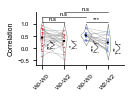

Shapiro-Wilk test for CKII W0_W0: ShapiroResult(statistic=0.8516841936948207, pvalue=0.0036361854059345994)
Shapiro-Wilk test for CKII W0_W2: ShapiroResult(statistic=0.901483228143932, pvalue=0.031830944171509355)
data is not normally distributed, using Wilcoxon signed-rank test
Signed-rank test for CKII W0_W0 vs W0_W2: WilcoxonResult(statistic=51.0, pvalue=0.01272726058959961)

CKII W0_W0 mean: 6.998, SEM: 1.345
CKII W0_W2 mean: 12.409, SEM: 1.708
P-value for CKII W0_W0 vs shuffled: 0.000
P-value for CKII W0_W2 vs shuffled: 0.030
Shapiro-Wilk test for SST W0_W0: ShapiroResult(statistic=0.8932969024719982, pvalue=0.05252819634195052)
Shapiro-Wilk test for SST W0_W2: ShapiroResult(statistic=0.845230467887361, pvalue=0.009078139258311307)
data is not normally distributed, using Wilcoxon signed-rank test
Signed-rank test for SST W0_W0 vs W0_W2: WilcoxonResult(statistic=33.0, pvalue=0.0395355224609375)

SST W0_W0 mean: 7.388, SEM: 1.502
SST W0_W2 mean: 12.662, SEM: 2.689
P-value for SST W0

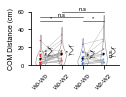

In [ ]:
def plot_combined_W0_W2_violins_with_histograms(result_dicts, shuffled_distributions_list, group_labels,
                                                palette_list, ylabel=False,
                                                yticks=np.arange(-0.5, 1.1, 0.5), ylims=(-0.7, 1.5),
                                                save_path=None, SVG_TICKS=6, SVG_LABELS=6,
                                                figsize_mm=(25, 25), offset=0.3,y_sig=1.1,sig_offsets=[0.2,0.4]):
    from scipy.stats import gaussian_kde
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    assert len(result_dicts) == 2 and len(shuffled_distributions_list) == 2

    # Collect data
    all_violin_data = []
    all_group_pos = []
    violin_labels = ["W0-W0", "W0-W2", "W0-W0", "W2-W2"]

    fig, ax = plt.subplots(figsize=(figsize_mm[0] / 25.4, figsize_mm[1] / 25.4))

    # --- Violin plotting first ---
    all_violin_data = []
    for result_dict in result_dicts:
        W0 = [res['W0_W0'] for res in result_dict.values()]
        W2 = [res['W0_W2'] for res in result_dict.values()]
        all_violin_data.extend([W0, W2])

    sns.violinplot(data=all_violin_data, ax=ax, color='white', linewidth=0.5, width=0.5,
                   inner=None, zorder=0)

    for collection in ax.collections:
        collection.set_edgecolor('gray')
    for line in ax.lines:
        line.set_color('black')
        line.set_linewidth(0.5)

    # --- Plot everything else (scatter, KDEs) on top ---
    for group_idx, (result_dict, shuffled_distributions, group_label, palette) in enumerate(
        zip(result_dicts, shuffled_distributions_list, group_labels, palette_list)):

        W0 = [res['W0_W0'] for res in result_dict.values()]
        W2 = [res['W0_W2'] for res in result_dict.values()]
        x_offset = group_idx * 2

        jitter_0 = np.random.normal(0, 0.02, size=len(W0))
        jitter_1 = np.random.normal(0, 0.02, size=len(W2))

        # Scatter plots — add zorder=2 to ensure visibility
        ax.scatter(np.zeros(len(W0)) + x_offset + jitter_0, W0,
                facecolors=palette[0], edgecolors='none', linewidths=0,
                s=2, alpha=0.8, marker='o', zorder=2)

        ax.scatter(np.ones(len(W2)) + x_offset + jitter_1, W2,
                facecolors=palette[1], edgecolors='none', linewidths=0,
                s=2, alpha=0.8, marker='o', zorder=2)

        # Connecting lines
        for i in range(len(W0)):
            ax.plot([x_offset + 0 + jitter_0[i], x_offset + 1 + jitter_1[i]],
                    [W0[i], W2[i]], color='gray', alpha=0.5, linewidth=0.5, zorder=1.5)

        # Mean points
        ax.scatter(x_offset + 0, np.mean(W0),
           facecolors='k', edgecolors='none', linewidths=0,
           s=5, marker='o', zorder=3)

        ax.scatter(x_offset + 1, np.mean(W2),
                facecolors='k', edgecolors='none', linewidths=0,
                s=5, marker='o', zorder=3)

        
        shapir_wilk_W0 = stats.shapiro(W0)
        shapir_wilk_W2 = stats.shapiro(W2)
        print(f"Shapiro-Wilk test for {group_label} W0_W0: {shapir_wilk_W0}")
        print(f"Shapiro-Wilk test for {group_label} W0_W2: {shapir_wilk_W2}")
        if shapir_wilk_W0.pvalue < 0.05 or shapir_wilk_W2.pvalue < 0.05:
            p=stats.wilcoxon(W0, W2)[1]
            print("data is not normally distributed, using Wilcoxon signed-rank test")
            print(f"Signed-rank test for {group_label} W0_W0 vs W0_W2: {stats.wilcoxon(W0, W2)}")
        else:
            p = stats.ttest_rel(W0, W2)[1]
            print("data is normally distributed, using paired t-test")
            print(f"Paired t-test for {group_label} W0_W0 vs W0_W2: {stats.ttest_rel(W0, W2)}")
        # sig_y = max(max(W0), max(W2)) + 0.05
        sig_y=y_sig
        x0 = x_offset
        x1 = x_offset + 1
        line_y = sig_y - 0.01  # line just under the text

        # Determine label
        if p > 0.05:
            sig_label = "n.s"
        elif p < 0.001:
            sig_label = "***"
        elif p < 0.01:
            sig_label = "**"
        else:
            sig_label = "*"
        # Print means and SEM
        print(f"\n{group_label} W0_W0 mean: {np.mean(W0):.3f}, SEM: {np.std(W0)/np.sqrt(len(W0)):.3f}")
        print(f"{group_label} W0_W2 mean: {np.mean(W2):.3f}, SEM: {np.std(W2)/np.sqrt(len(W2)):.3f}")
        # Draw line and text
        ax.plot([x0, x1], [line_y, line_y], color='k', linewidth=0.5)
        ax.text((x0 + x1)/2, sig_y, sig_label, ha='center', va='bottom', fontsize=SVG_TICKS)


        # KDEs
        for i, shuffled in enumerate(shuffled_distributions):
            kde = gaussian_kde(shuffled)
            y_vals = np.linspace(min(shuffled), max(shuffled), 300)
            density = kde(y_vals)
            density = density / np.max(density) * 0.2
            x_pos = x_offset + i + offset
            ax.plot(x_pos + density, y_vals, color='k', linewidth=0.7, alpha=0.7)

            lower, upper = np.percentile(shuffled, [1, 99])
            ax.plot([x_pos, x_pos + 0.2], [lower, lower], color='k', linestyle='--', linewidth=0.6)
            ax.plot([x_pos, x_pos + 0.2], [upper, upper], color='k', linestyle='--', linewidth=0.6)

            obs_mean = np.mean(W0) if i == 0 else np.mean(W2)
            p_val = 2 * min(np.mean(shuffled >= obs_mean), np.mean(shuffled <= obs_mean))
            y_peak = y_vals[np.argmax(density)]
            print(f"P-value for {group_label} W0_W0 vs shuffled: {p_val:.3f}" if i == 0 else f"P-value for {group_label} W0_W2 vs shuffled: {p_val:.3f}")

            if p_val > 0.05:
                shuffle_sig = "n.s."
            elif p_val < 0.001:
                shuffle_sig = "***"
            elif p_val < 0.01:
                shuffle_sig = "**"
            else:
                shuffle_sig = "*"
            ax.text(x_pos, y_peak, shuffle_sig, ha='center', va='center', fontsize=SVG_TICKS, rotation=90)
    # Between-group t-tests: CKII vs SST at W0_W0 and W0_W2
    CKII_W0 = [res['W0_W0'] for res in result_dicts[0].values()]
    CKII_W2 = [res['W0_W2'] for res in result_dicts[0].values()]
    SST_W0  = [res['W0_W0'] for res in result_dicts[1].values()]
    SST_W2  = [res['W0_W2'] for res in result_dicts[1].values()]

    comparisons = [
        (CKII_W0, SST_W0, 0, 2, sig_offsets[0]),  # CKII W0 vs SST W0
        (CKII_W2, SST_W2, 1, 3, sig_offsets[1])   # CKII W2 vs SST W2
    ]

    for vals1, vals2, x1, x2,offset in comparisons:
        p = stats.ttest_ind(vals1, vals2)[1]
        y1 = sig_y + offset
        line_y = y1 - 0.01

        if p > 0.05:
            label = "n.s"
        elif p < 0.001:
            label = "***"
        elif p < 0.01:
            label = "**"
        else:
            label = "*"

        ax.plot([x1, x2], [line_y, line_y], color='k', linewidth=0.5)
        ax.text((x1 + x2)/2, y1, label, ha='center', va='bottom', fontsize=SVG_TICKS)
        print(f"Between-group t-test W0_W0 (CKII vs SST): p-value = {p:.3f}" if x1==0 else f"Between-group t-test W0_W2 (CKII vs SST): p-value = {p:.3f}")
    # Aesthetics
    ax.set_ylim(ylims)
    ax.set_yticks(yticks)
    ax.tick_params(axis='y', labelsize=SVG_TICKS)
    ax.set_xticks([0, 1, 2, 3], violin_labels, fontsize=SVG_TICKS, rotation=45)

    if ylabel:
        ax.set_ylabel(ylabel, fontsize=SVG_LABELS)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.patch.set_facecolor('none')

    if save_path:
        plt.savefig(save_path, dpi=300, format=save_path.split('.')[-1], bbox_inches='tight')

    plt.show()



plot_combined_W0_W2_violins_with_histograms(
    result_dicts=[corrs_CKII, corrs_SST],
    shuffled_distributions_list=[
        [shuffled_means_CKII_corr_w0, shuffled_means_CKII_corr_w2],
        [shuffled_means_SST_corr_w0, shuffled_means_SST_corr_w2]
    ],
    group_labels=["CKII", "SST"],
    palette_list=[
        [PYR_COLOR, PYR_COLOR_weak],
        [IN_COLOR, IN_COLOR_weak]
    ],
    ylabel="Correlation",
    yticks=np.arange(-0.5, 1.1, 0.5),
    ylims=(-0.7, 1.5),
    save_path=None, 
    SVG_TICKS=SVG_TICKS,
    SVG_LABELS=SVG_LABELS,
    figsize_mm=(40, 25),
    offset=0.35
)



plot_combined_W0_W2_violins_with_histograms(
    result_dicts=[COM_CKII, COM_SST],
    shuffled_distributions_list=[
        [shuffled_means_CKII_COM_w0, shuffled_means_CKII_COM_w2],
        [shuffled_means_SST_COM_w0, shuffled_means_SST_COM_w2]
    ],
    group_labels=["CKII", "SST"],
    palette_list=[
        [PYR_COLOR, PYR_COLOR_weak],
        [IN_COLOR, IN_COLOR_weak]
    ],
    ylabel="COM Distance (cm)",
    yticks=np.arange(0, 61, 20),
    ylims=(0, 60),
    save_path=None, # "your_save_path_here"
    SVG_TICKS=SVG_TICKS,
    SVG_LABELS=SVG_LABELS,
    figsize_mm=(40, 25),
    offset=0.35,
    y_sig=50,
    sig_offsets= [4, 10]  # Adjust offsets for significance lines if needed
)


# 6e

In [42]:
strain = "SST"
time_interval = [11, 15]
all_strain_IDs = list(set(cell.identity for cell in cell_objects if cell.strain == strain))
inst_r_vals_w0_frst_half_control = []; inst_r_vals_w0_scnd_half_control = []
inst_r_vals_w0_frst_half_longi =[]; inst_r_vals_w2_frst_half_longi =[]
inst_r_vals_w0_frst_half_control_all_cells = []; inst_r_vals_w0_scnd_half_control_all_cells = []
inst_r_vals_w0_frst_half_longi_all_cells = []; inst_r_vals_w2_frst_half_longi_all_cells = []   
results_dict_to_export = {}

for id in all_strain_IDs:
    max_pair = get_session_pair_by_PC(
        id,
        time_interval=time_interval,
        include_remap=True,
        require_first_regular=True,
        require_first_regular_second_remap=False
    )
    if len(max_pair) == 0:
        continue
    inst_r_val_w0_frst = inst_speed_r_vals_with_halves_all_cells[max_pair[0].strain][max_pair[0].name]['first_half']
    inst_r_val_w0_scnd = inst_speed_r_vals_with_halves_all_cells[max_pair[0].strain][max_pair[0].name]['second_half']
    inst_r_val_w2_frst = inst_speed_r_vals_with_halves_all_cells[max_pair[1].strain][max_pair[1].name]['first_half']
    inst_r_vals_w0_frst_half_control_all_cells.append(inst_r_val_w0_frst)
    inst_r_vals_w0_scnd_half_control_all_cells.append(inst_r_val_w0_scnd)
    inst_r_vals_w0_frst_half_longi_all_cells.append(inst_r_val_w0_frst)
    inst_r_vals_w2_frst_half_longi_all_cells.append(inst_r_val_w2_frst)
    results_dict_to_export[max_pair[0].identity] = {
        'Strain': max_pair[0].strain,
        'W0_First_Half_Inst_Speed_R': inst_r_val_w0_frst,
        'W0_Second_Half_Inst_Speed_R': inst_r_val_w0_scnd,
        'W2_First_Half_Inst_Speed_R': inst_r_val_w2_frst
    }
    
    
    if is_speed_tuned_with_halves_all_cells[max_pair[0].strain][max_pair[0].name]['first_half'] == True or \
         is_speed_tuned_with_halves_all_cells[max_pair[1].strain][max_pair[1].name]['first_half'] == True:
          inst_r_vals_w0_frst_half_longi.append(inst_r_val_w0_frst)
          inst_r_vals_w2_frst_half_longi.append(inst_r_val_w2_frst)
          inst_r_vals_w0_frst_half_control.append(inst_r_val_w0_frst)
          inst_r_vals_w0_scnd_half_control.append(inst_r_val_w0_scnd)




In [54]:
def generate_n_shuffled_means_on_array_diffs(array1, array2, n_shuffles=10000):
    """
    Generate n shuffled means on the differences between two arrays.
    """
    diffs = np.abs(array1 - array2)
    observed_mean = np.mean(diffs)
    shuffled_means = []
    for _ in range(n_shuffles):
        shuffled_array1 = np.random.permutation(array1)
        shuffled_mean = np.mean(np.abs(shuffled_array1 - array2))
        shuffled_means.append(shuffled_mean)
    shuffled_means = np.array(shuffled_means)
    p_value = (np.sum(shuffled_means <= observed_mean) + 1) / (n_shuffles + 1)
    return diffs,observed_mean, shuffled_means, p_value

# Define datasets
datasets = [
    ('W0-W0', inst_r_vals_w0_frst_half_control, inst_r_vals_w0_scnd_half_control),
    ('W0-W2', inst_r_vals_w0_frst_half_longi, inst_r_vals_w2_frst_half_longi)
]

# Initialize result storage
results = {}

# Loop and compute
print("Mean vs. Shuffled Mean disribution:\n")
for name, arr1, arr2 in datasets:
    diffs,observed_mean, shuffled_means, p_value = generate_n_shuffled_means_on_array_diffs(np.array(arr1), np.array(arr2))
    results[name] = {
        'diffs': diffs,
        'observed_mean': observed_mean,
        'shuffled_means': shuffled_means,
        'p_value': p_value
    }
    print(f"{name}:")
    print(f"  p-value: {p_value:.4f}\n")


Mean vs. Shuffled Mean disribution:

W0-W0:
  p-value: 0.0003

W0-W2:
  p-value: 0.1374



Shapiro-W0: 0.3699081321310225, Shapiro-W2: 0.05423615389949004
TtestResult(statistic=-2.2524081626512147, pvalue=0.03371510266946146, df=24)
Mean W0: 0.115 ± 0.013, Mean W2: 0.172 ± 0.026


(<Figure size 70.8661x70.8661 with 1 Axes>, <Axes: >)

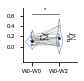

In [45]:
def plot_W0_W2_violins_with_histograms(result_dict, shuffled_distributions, cell_name,
                                       palette=[PYR_COLOR, PYR_COLOR_weak],
                                       ylabel=False, yticks=np.arange(-0.5, 1.1, 0.5), ylims=(-0.7, 1.5),
                                       save_path=None, SVG_TICKS=6, SVG_LABELS=6, figsize_mm=(12.5, 25),
                                       rotation =0, title='',offset=0.3, paired=True, key_type='W0W2'):
    from scipy.stats import gaussian_kde, ttest_rel, ttest_ind

    # Determine keys based on key_type
    if key_type == 'W0W2':
        key1, key2 = 'W0_W0', 'W0_W2'
        xtick_labels = ['W0-W0', 'W0-W2']
    elif key_type == 'RegRemap':
        key1, key2 = 'Reg', 'Remap'
        xtick_labels = ['Reg', 'Remap']
    else:
        raise ValueError("key_type must be either 'W0W2' or 'RegRemap'")
    if paired:
        W0_values = [res[key1] for res in result_dict.values()]
        W2_values = [res[key2] for res in result_dict.values()]
    else:
        W0_values = result_dict[key1]
        W2_values = result_dict[key2]
    shuffled_means = [np.mean(dist) for dist in shuffled_distributions]

    # Stats: paired or unpaired
    shapiro_w0 = stats.shapiro(W0_values)[1]
    shapiro_w2 = stats.shapiro(W2_values)[1]
    print(f"Shapiro-W0: {shapiro_w0}, Shapiro-W2: {shapiro_w2}")
    if shapiro_w0 < 0.05 or shapiro_w2 < 0.05:
        print("Data is not normally distributed, using non-parametric test.")
        if paired:
            p = stats.wilcoxon(W0_values, W2_values)[1]
            print(stats.wilcoxon(W0_values, W2_values))
        else:
            p = stats.ranksums(W0_values, W2_values)[1]
        print(stats.ranksums(W0_values, W2_values))
    else:
        if paired:
            p = ttest_rel(W0_values, W2_values)[1]
            print(stats.ttest_rel(W0_values, W2_values))
        else:
            p = ttest_ind(W0_values, W2_values)[1]
            print(stats.ttest_ind(W0_values, W2_values))

    # Setup
    figsize_inch = (figsize_mm[0] / 25.4, figsize_mm[1] / 25.4)
    fig, ax = plt.subplots(figsize=figsize_inch)

    # Violin plots
    sns.violinplot(data=[W0_values, W2_values], color='white', linewidth=0.5, width=0.5,
                   zorder=0, alpha=1, inner=None, ax=ax)
    for collection in ax.collections:
        collection.set_edgecolor('gray')
    for line in ax.lines:
        line.set_color('black')
        line.set_linewidth(0.5)

    # Scatter points with jitter
    jitter_0 = np.random.normal(0, 0.02, size=len(W0_values))
    jitter_1 = np.random.normal(0, 0.02, size=len(W2_values))
    ax.scatter(np.zeros(len(W0_values)) + jitter_0, W0_values, color=palette[0], s=2, alpha=0.8, edgecolors='none')
    ax.scatter(np.ones(len(W2_values)) + jitter_1, W2_values, color=palette[1], s=2, alpha=0.8, edgecolors='none')

    # Connect lines (only if paired)
    if paired:
        for i in range(min(len(W0_values), len(W2_values))):
            ax.plot([0 + jitter_0[i], 1 + jitter_1[i]], [W0_values[i], W2_values[i]],
                    color='gray', alpha=0.5, linewidth=0.5)

    # Mean points
    ax.scatter(0, np.mean(W0_values), color='k', s=2, zorder=2)
    ax.scatter(1, np.mean(W2_values), color='k', s=2, zorder=2)
    
    #print mean and SEM
    mean_w0 = np.mean(W0_values)
    sem_w0 = stats.sem(W0_values)
    mean_w2 = np.mean(W2_values)
    sem_w2 = stats.sem(W2_values)
    print(f"Mean W0: {mean_w0:.3f} ± {sem_w0:.3f}, Mean W2: {mean_w2:.3f} ± {sem_w2:.3f}")
    

    # KDE histograms
    histogram_offset = offset
    for i, (shuffled, x_center) in enumerate(zip(shuffled_distributions, [0, 1])):
        kde = gaussian_kde(shuffled)
        y_vals = np.linspace(min(shuffled), max(shuffled), 300)
        density = kde(y_vals)
        density = density / np.max(density) * 0.2
        ax.plot(x_center + histogram_offset + density, y_vals, color='k', linewidth=0.7, alpha=0.7)
        lower, upper = np.percentile(shuffled, [1, 99])
        ax.plot([x_center + histogram_offset, x_center + histogram_offset + 0.2], [lower, lower],
                color='k', linestyle='--', linewidth=0.6)
        ax.plot([x_center + histogram_offset, x_center + histogram_offset + 0.2], [upper, upper],
                color='k', linestyle='--', linewidth=0.6)
        obs_mean = np.mean(W0_values) if i == 0 else np.mean(W2_values)
        p_val = 2 * min(np.mean(shuffled >= obs_mean), np.mean(shuffled <= obs_mean))
        y_peak = y_vals[np.argmax(density)]
        if p_val > 0.05:
            shuffle_sig = "n.s."
        elif p_val < 0.001:
            shuffle_sig = "***"
        elif p_val < 0.01:
            shuffle_sig = "**"
        else:
            shuffle_sig = "*"
        ax.text(x_center + histogram_offset, y_peak, shuffle_sig, ha='center', va='center',
                fontsize=SVG_TICKS, rotation=90)

    # Y axis
    ax.set_ylim(ylims)
    ax.set_yticks(yticks)
    ax.tick_params(axis='y', labelsize=SVG_TICKS)
    ax.set_xticks([0, 1], xtick_labels, fontsize=SVG_TICKS, rotation=rotation)
    ax.set_title(title, fontsize=SVG_LABELS)

    # Overall significance annotation
    y_lim = ax.get_ylim()
    x_center = 0.5
    if p > 0.05:
        sig_label = "n.s"
    elif p < 0.001:
        sig_label = "***"
    elif p < 0.01:
        sig_label = "**"
    else:
        sig_label = "*"
    ax.text(x_center, y_lim[1] * 0.9, sig_label, ha='center', va='bottom', color='k', fontsize=SVG_TICKS)
    #plot a line below the significance label
    plt.plot([0, 1], [y_lim[1] * 0.85, y_lim[1] * 0.85], color='k', linewidth=0.5)

    if ylabel:
        ax.set_ylabel(ylabel, fontsize=SVG_LABELS)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.patch.set_facecolor('none')

    if save_path:
        plt.savefig(save_path, dpi=300, format=save_path.split('.')[-1], bbox_inches='tight')

    return fig, ax


r_vals_longi_dict_inst = {}
for i in np.arange(len(results['W0-W0 (inst) ST']['diffs'])):
    r_vals_longi_dict_inst[i] = {
        'W0_W0': results['W0-W0 (inst) ST']['diffs'][i],
        'W0_W2': results['W0-W2 (inst) ST']['diffs'][i]
    }

plot_W0_W2_violins_with_histograms(r_vals_longi_dict_inst,[results['W0-W0 (inst) ST']['shuffled_means'],
                            results['W0-W2 (inst) ST']['shuffled_means']], "SST", palette=[IN_COLOR, IN_COLOR_weak],
                            ylabel="", yticks=[0,0.2,0.4,0.6], ylims=(-0.3, 0.75),
                            save_path=False,
                            SVG_TICKS=SVG_TICKS, SVG_LABELS=SVG_LABELS,figsize_mm=(25, 25),offset=0.4,title='')


# 6f

In [ ]:
from matplotlib.patches import PathPatch
from matplotlib.path import Path

def create_bezier_curve(x1, y1, x2, y2, curvature=0.4):
    verts = [(x1, y1), (x1 + curvature, y1), (x2 - curvature, y2), (x2, y2)]
    codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4]
    return Path(verts, codes)

def calculate_positions(counts, categories, spacing):
    return np.cumsum([counts[cat] + spacing for cat in categories]) - \
           np.array([(counts[cat] + spacing) / 2 for cat in categories])

def compute_ordered_y_positions(counts, positions, categories):
    return {
        cat: [positions[i] - counts[cat]/2 + j + 0.5 for j in range(counts[cat])]
        for i, cat in enumerate(categories)
    }

def plot_sankey_svg_style(
    fam_counts, nov_counts, transitions, strain,
    figsize_mm=(30, 60), svg_label_size=10, spacing=5,
    xticklabels=("Fam 1", "Fam 2"), svg_path=None
):
    if strain == "CKII":
        categories = ["tuned", "non-tuned"]
    else:
        categories = ["speed", "both", "space", "uniform", "non-tuned"]

    colors = {
        "speed": "blue", "space": "green", "both": "purple",
        "uniform": "orange", "non-tuned": "gray", "tuned": "green"
    }

    # Compute stacked positions
    fam_pos = calculate_positions(fam_counts, categories, spacing)
    nov_pos = calculate_positions(nov_counts, categories, spacing)

    # Prepare transitions
    sorted_transitions = {cat: [] for cat in categories}
    for f, n in transitions:
        sorted_transitions[f].append((f, n))
    for cat in categories:
        sorted_transitions[cat].sort(key=lambda x: categories.index(x[1]))

    # Setup figure
    figsize_inch = (figsize_mm[0]/25.4, figsize_mm[1]/25.4)
    fig, ax = plt.subplots(figsize=figsize_inch)
    x_fam, x_nov = 0, 1

    # Draw stacked bars
    for i, cat in enumerate(categories):
        ax.bar(x_fam, fam_counts[cat], bottom=fam_pos[i] - fam_counts[cat]/2,
               width=0.2, color=colors[cat], edgecolor="black", linewidth=0.3)
        ax.bar(x_nov, nov_counts[cat], bottom=nov_pos[i] - nov_counts[cat]/2,
               width=0.2, color=colors[cat], edgecolor="black", linewidth=0.3)

    # Compute curve anchors
    fam_y = compute_ordered_y_positions(fam_counts, fam_pos, categories)
    nov_y = compute_ordered_y_positions(nov_counts, nov_pos, categories)

    # Draw curves
    for fam_cat in categories:
        for _, nov_cat in sorted_transitions[fam_cat]:
            if fam_y[fam_cat] and nov_y[nov_cat]:
                y1 = fam_y[fam_cat].pop(0)
                y2 = nov_y[nov_cat].pop(0)
                path = create_bezier_curve(x_fam + 0.1, y1, x_nov - 0.1, y2)
                patch = PathPatch(path, facecolor='none', edgecolor=colors[fam_cat], alpha=0.7, lw=1)
                ax.add_patch(patch)

    # Format axes
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(0, max(fam_pos[-1], nov_pos[-1]) + spacing)
    ax.set_xticks([x_fam, x_nov])
    ax.set_xticklabels(xticklabels, fontsize=svg_label_size)
    ax.set_yticks([])
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    # Output
    plt.tight_layout()
    if svg_path:
        plt.savefig(svg_path, format='svg')
    plt.show()

def classify_cells_longi(cell, strain, cond):
    if is_PC_with_halves_all_cells[strain][cell.name][cond] and is_speed_tuned_with_halves_all_cells[strain][cell.name][cond]:
        return "both"
    elif is_speed_tuned_with_halves_all_cells[strain][cell.name][cond]:
        return "speed"
    elif is_PC_with_halves_all_cells[strain][cell.name][cond]:
        return "space"
    elif not is_spatially_modulated_all_cells[strain][cell.name][cond]:
        return "uniform"
    else:
        return "non-tuned"
    
categories = ["speed","both", "space",  "uniform", "non-tuned"]
colors = {
    "speed": "blue",
    "space": "green",
    "both": "purple",
    "uniform": "orange",
    "non-tuned": "gray",
    "tuned": "green"}

## W0-W0 control

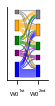

In [36]:
strain = "SST"
time_interval = [11, 15]  # Days between sessions
# Initialize data structures
cell_transitions_control = []  # List of (fam_class, nov_class) transitions
cell_transitions_inst_r_control = []  # List of (fam_class, nov_class) transitions
W0_1_counts = {cat: 0 for cat in categories}
W0_2_counts = {cat: 0 for cat in categories}
W0_1_counts_inst_r = {cat: 0 for cat in categories}
W0_2_counts_inst_r = {cat: 0 for cat in categories}

all_strain_IDs = list(set(cell.identity for cell in cell_objects if cell.strain == strain))
results_dict_to_export = {}
for id in all_strain_IDs:
    max_pair = get_session_pair_by_PC(
        id,
        time_interval=time_interval,
        include_remap=True,
        require_first_regular=True,
        require_first_regular_second_remap=False
    )
    if len(max_pair) == 0:
        continue

    # Classify cell in 'fam' and 'nov' environments

    else:
        w0_1_class = classify_cells_longi(max_pair[0], max_pair[0].strain, 'first_half')
        w0_2_class = classify_cells_longi(max_pair[0], max_pair[0].strain, 'second_half')
        results_dict_to_export[max_pair[0].identity] = {
            'Strain': max_pair[0].strain,
            'W0_1_Class': w0_1_class,
            'W0_2_Class': w0_2_class
        }



    # Add the transition to the list
    cell_transitions_control.append((w0_1_class, w0_2_class))
    # Count occurrences for fam and nov categories
    W0_1_counts[w0_1_class] += 1
    W0_2_counts[w0_2_class] += 1

plot_sankey_svg_style(W0_1_counts, W0_2_counts, cell_transitions_control, strain="SST", 
                        figsize_mm=(22, 40), svg_label_size=6,
                        xticklabels=("$\mathregular{W0^{1st}}$", "$\mathregular{W0^{2nd}}$"), svg_path=r'your_save_path_here')

## W0-W2 

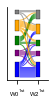

In [40]:
strain = "SST"
time_interval = [11, 15]  # Days between sessions
# Initialize data structures
cell_transitions_longi = []  # List of (fam_class, nov_class) transitions
cell_transitions_inst_r_longi = []  # List of (fam_class, nov_class) transitions
W0_counts = {cat: 0 for cat in categories}
W2_counts = {cat: 0 for cat in categories}
W0_counts_inst_r = {cat: 0 for cat in categories}
W2_counts_inst_r = {cat: 0 for cat in categories}

all_strain_IDs = list(set(cell.identity for cell in cell_objects if cell.strain == strain))

for id in all_strain_IDs:
    max_pair = get_session_pair_by_PC(
        id,
        time_interval=time_interval,
        include_remap=True,
        require_first_regular=True,
        require_first_regular_second_remap=False
    )
    if len(max_pair) == 0:
        continue

    # Classify cell in 'fam' and 'nov' environments

    else:
        w0_class = classify_cells_longi(max_pair[0], max_pair[0].strain, 'first_half')
        w2_class = classify_cells_longi(max_pair[1], max_pair[1].strain, 'first_half')
        #update results dict to export with w2_class
        results_dict_to_export[max_pair[0].identity].update({
            'W2_Class': w2_class
        })

    # Add the transition to the list
    cell_transitions_longi.append((w0_class, w2_class))


    # Count occurrences for fam and nov categories
    W0_counts[w0_class] += 1
    W2_counts[w2_class] += 1

    
plot_sankey_svg_style(W0_counts, W2_counts, cell_transitions_longi, strain="SST", 
                        figsize_mm=(22, 40), svg_label_size=6, 
                        xticklabels=("$\mathregular{W0^{1st}}$", "$\mathregular{W2^{1st}}$"), svg_path=r'your_save_path_here')

